In [1]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")

using Pkg
Pkg.precompile()

using Plots, JLD2, LaTeXStrings, FileIO

### Time Scaling of MCWF for single trajectory

In [7]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/N_atoms=3_γ_decay=0.001_Ntraj=1_trial.jld2"
a1 = population_a
a2 = population_c
a3 = population_ac;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/N_atoms=5_γ_decay=0.001_Ntraj=1_trial.jld2"
b1 = population_a
b2 = population_c
b3 = population_ac;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/N_atoms=9_γ_decay=0.001_Ntraj=1_trial.jld2"
c1 = population_a
c2 = population_c
c3 = population_ac;


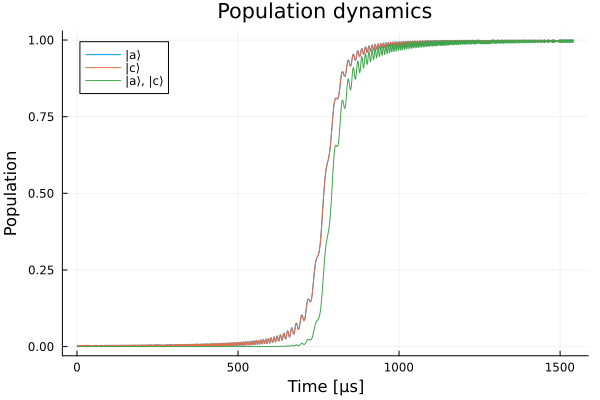

In [5]:
plot(a1, label="|a⟩", xlabel="Time [μs]", ylabel="Population", title="Population dynamics")
plot!(a2, label="|c⟩")
plot!(a3, label="|a⟩, |c⟩")

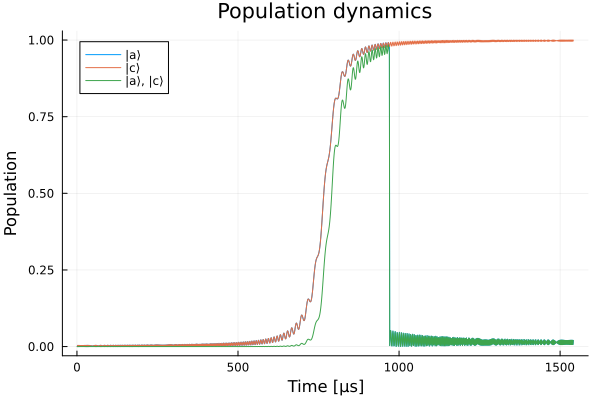

In [6]:
plot(b1, label="|a⟩", xlabel="Time [μs]", ylabel="Population", title="Population dynamics")
plot!(b2, label="|c⟩")
plot!(b3, label="|a⟩, |c⟩")

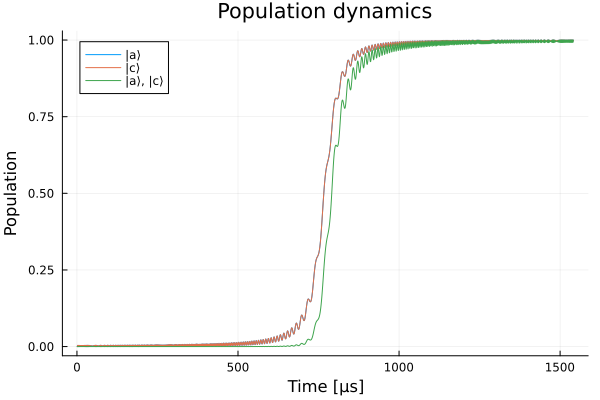

In [8]:
plot(c1, label="|a⟩", xlabel="Time [μs]", ylabel="Population", title="Population dynamics")
plot!(c2, label="|c⟩")
plot!(c3, label="|a⟩, |c⟩")

### Benchmarking MCWF

In [118]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/master_γ_decay=0.001.jld2"
ρt_exact = ρt;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=1.jld2"
ρt_1 = ρ_avg;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=5.jld2"
ρt_5 = ρ_avg;

@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=10.jld2"
ρt_10 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=50.jld2"
ρt_50 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=100.jld2"
ρt_100 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=500.jld2"
ρt_500 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=1000.jld2"
ρt_1000 = ρ_avg;

@load"/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/benchmark_data/mcwf_γ_decay=0.001_Ntraj=5000.jld2"
ρt_5000 = ρ_avg;

In [119]:
T1 = []
T5 = []
T10 = []
T50 = []
T100 = []
T500 = []
T1000 = []
T5000 = []
for i in 1:length(ρt_exact)
    param = 0.5 * real(tr(abs.((ρt_exact[i].data .- ρt_1[i]))))
    push!(T1, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_5[i])))
    push!(T5, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_10[i])))
    push!(T10, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_50[i])))
    push!(T50, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_100[i])))
    push!(T100, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_500[i])))
    push!(T500, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_1000[i])))
    push!(T1000, param)
    param = 0.5 * real(tr(abs.(ρt_exact[i].data .- ρt_5000[i])))
    push!(T5000, param)
end

T1[T1 .<=0] .= 1e-5
T5[T5 .<=0] .= 1e-5
T10[T10 .<=0] .= 1e-5
T50[T50 .<=0] .= 1e-5
T100[T100 .<=0] .= 1e-5
T500[T500 .<=0] .= 1e-5
T1000[T1000 .<=0] .= 1e-5
T5000[T5000 .<=0] .= 1e-5;

In [22]:
# Custom yticks from 10^-6 to 10^-1
ytick_values = 10.0 .^ (-8:-1)  # Generate ticks from 10^-6 to 10^-1
ytick_labels = ["10^{$i}" for i in -8:-1]  # LaTeX-style labels

# plot(tspan, T1, yscale=:log10, label="1 trajectory", yticks=(ytick_values,ytick_labels), xlabel="Time", ylabel="Trace distance", title="Benchmarking MCWF simulation",legend=:bottomright)
# plot(tspan, T5, yscale=:log10, label="5 trajectories",xlabel="Time", ylabel="Trace distance", title="Benchmarking MCWF simulation",legend=:bottomright)
# plot!(tspan, T10, label="10 trajectories")
# plot!(tspan, T50, label="50 trajectories")
# plot!(tspan, T100, label="100 trajectories")
# plot!(tspan, T500, label="500 trajectories")
plot!(tspan, T1000, label="1000 trajectories")
plot!(tspan, T5000, label="5000 trajectories")

UndefVarError: UndefVarError: `T1000` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [62]:
basis = NLevelBasis(2)
k = transition(basis,2,2)
n_a = full_operator(k,total_qubits, [1])
n_c = full_operator(k, total_qubits, [3])
n_ac = full_operator(k, total_qubits, [1,3]);

pop_a1 = []
pop_a5 = []
pop_a10 = []
pop_a50 = []
pop_a100 = []
pop_a500 = []
pop_a1000 = []
pop_a5000 = []
pop_aexact = []

for i in 1:length(ρt_exact)
    push!(pop_aexact , real(expect(n_ac, ρt_exact[i])))
    push!(pop_a1, real(tr(n_ac.data*ρt_1[i])))
    push!(pop_a5, real(tr(n_ac.data*ρt_5[i])))
    push!(pop_a10, real(tr(n_ac.data*ρt_10[i])))
    push!(pop_a50, real(tr(n_ac.data*ρt_50[i])))
    push!(pop_a100, real(tr(n_ac.data*ρt_100[i])))
    push!(pop_a500, real(tr(n_ac.data*ρt_500[i])))
    push!(pop_a1000, real(tr(n_ac.data*ρt_1000[i])))
    push!(pop_a5000, real(tr(n_ac.data*ρt_5000[i])))
end

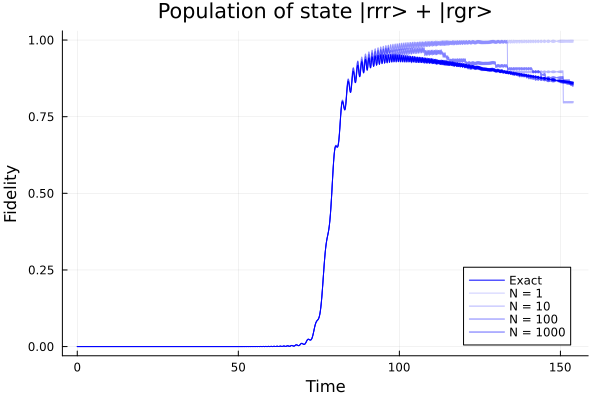

In [117]:
plot(tspan,pop_aexact, label="Exact", xlabel="Time", ylabel="Fidelity", title="Population of state |rrr> + |rgr>", color=:blue, alpha=1, legend=:bottomright)
plot!(tspan, pop_a1, label="N = 1",color=:blue,alpha=0.2)
# plot!(tspan, pop_a5, label="N = 5")
plot!(tspan, pop_a10, label="N = 10",color=:blue,alpha=0.3)
# plot!(tspan, pop_a50, label="N = 50")
plot!(tspan, pop_a100, label="N = 100",color=:blue,alpha=0.5)
# plot!(tspan, pop_a500, label="N = 500")
plot!(tspan, pop_a1000, label="N = 1000",color=:blue,alpha=0.6)
# plot!(tspan, pop_a5000, label="N = 5000") 

### Benchmarking parallelized MCWF

In [20]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_atoms/N_atoms=5_γ_decay=0.001_Ntraj=5.jld2"

ψ = ψ
a1 = population_a
a2 = population_c
a3 = population_ac;

In [21]:
ψ[1][end]

Ket(dim=32)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
 -0.010210676f0 + 0.00802974f0im
          0.0f0 + 0.0f0im
                ⋮
          0.0f0 + 0.0f0im
 -0.001742615f0 + 0.00066464295f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
 -0.018347366f0 - 0.14065242f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im

In [19]:
ψ[1][end]

Ket(dim=32)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
 -0.010210676f0 + 0.00802974f0im
          0.0f0 + 0.0f0im
                ⋮
          0.0f0 + 0.0f0im
 -0.001742615f0 + 0.00066464295f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
 -0.018347366f0 - 0.14065242f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im
          0.0f0 + 0.0f0im

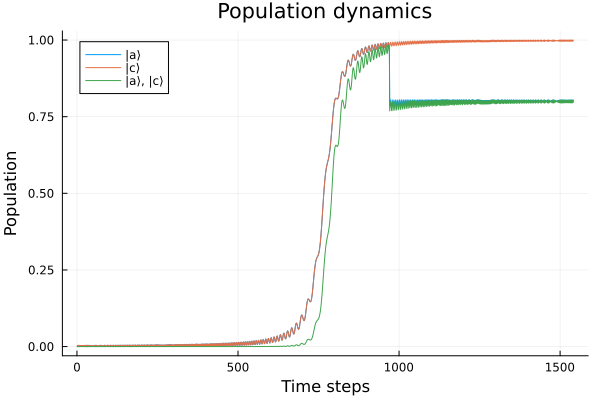

In [15]:
plot(a1, label="|a⟩", xlabel="Time steps", ylabel="Population", title="Population dynamics")
plot!(a2, label="|c⟩")
plot!(a3, label="|a⟩, |c⟩")